In [1]:
import yaml
from raft.raft_member import Member

import raft.member2Gmsh as m2g
# fname_design = "tests/test_data/mem_srf_vert_circ_cyl.yaml"
# fname_design ="tests/test_data/mem_subm_horz_rect_cyl.yaml"
# fname_design ="tests/test_data/mem_srf_inc_circ_cyl.yaml"
# fname_design ="examples/OC4semi-RAFT_QTF.yaml"
fname_design ="tests/test_data/mem_subm_horz_rect_cyl.yaml"

with open(fname_design) as file:
    design = yaml.load(file, Loader=yaml.FullLoader)

dict = design["members"][0]
mem = Member(dict, 1)

mem.setPosition()

m2g.memberMeshRect(mem.stations, mem.sl, mem.rA, mem.rB, index=0)
m2g.writeMesh(visual=True)

Exception: Degenerate box

In [1]:
import gmsh
import math
import os
import sys

gmsh.initialize()

gmsh.model.add("t19")

# Volumes can be constructed from (closed) curve loops thanks to the
# `addThruSections()' function
gmsh.model.occ.addCircle(0, 0, 0, 0.5, 1)
gmsh.model.occ.addCurveLoop([1], 1)
gmsh.model.occ.addCircle(0.1, 0.05, 1, 0.1, 2)
gmsh.model.occ.addCurveLoop([2], 2)
gmsh.model.occ.addCircle(-0.1, -0.1, 2, 0.3, 3)
gmsh.model.occ.addCurveLoop([3], 3)
gmsh.model.occ.addThruSections([1, 2, 3], 1)
gmsh.model.occ.synchronize()

gmsh.fltk.run()

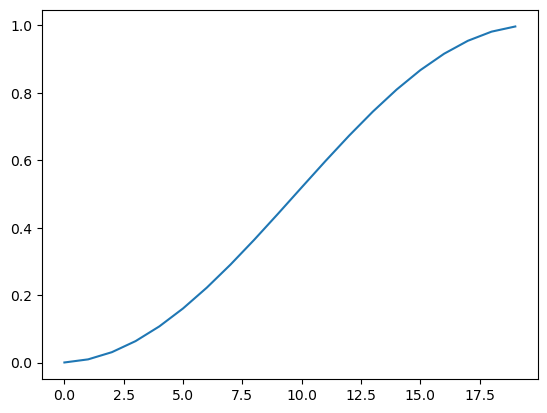

In [7]:
import numpy as np
nr = 20
grid_ = np.linspace(0, 1, nr, endpoint=False) + 0.5/nr
grid = 0.5*(np.sin(0.5*np.pi*(np.linspace(-1, 1, nr, endpoint=False) + 0.5/nr)) + 1)

import matplotlib.pyplot as plt

plt.plot(grid)

In [10]:
import gmsh
import sys

gmsh.initialize()
gmsh.option.setNumber('Mesh.MeshSizeMin', 0.02)
gmsh.option.setNumber('Mesh.MeshSizeMax', 0.02)
gmsh.model.occ.addPoint(-0.8, 0.1, -0.2, 1)
gmsh.model.occ.addPoint(-0.5, 0.1, -0.2, 2)
gmsh.model.occ.addPoint(-0.6, 0, -0.1, 3)
gmsh.model.occ.addPoint(-0.7, -0, -0.1, 4)
gmsh.model.occ.addPoint(-0.7, 0.2, -0.2, 5)
gmsh.model.occ.addPoint(-0.6, 0.1, -0.1, 6)
gmsh.model.occ.addSpline([1, 5, 2], 1)
gmsh.model.occ.addSpline([2, 6, 3], 2)
gmsh.model.occ.addSpline([3, 4, 1], 3)
gmsh.model.occ.addCurveLoop([1, 2, 3], 1)

# Bspline surface bounded by curve loop 1, constructed by optimization
gmsh.model.occ.addSurfaceFilling(1, 1)

# BSpline filling (try "Stretch" or "Curved")
gmsh.model.occ.addBSplineFilling(1, 2, 'Curved')

# Bezier filling - can be used if all bounding curves are Bezier curves
# gmsh.model.occ.addBezierFilling(1, 3)

# Same as 1, but passing through points 7 and 8
gmsh.model.occ.addPoint(-0.7, 0.1, -0.2, 7)
gmsh.model.occ.addPoint(-0.67, 0.1, -0.2, 8)
gmsh.model.occ.addSurfaceFilling(1, 4, [7, 8])

gmsh.model.occ.synchronize()

if '-nopopup' not in sys.argv:
    gmsh.fltk.run()

gmsh.finalize()


In [3]:
class B:
    def __init__(self, value):
        self.value = value

class A:
    def __init__(self, b_instance):
        # 传递引用，b_instance 是 B 的引用
        self.b_instance = b_instance

    def print_value(self):
        print(self.b_instance.value)

b = B(10)
a = A(b)  # 传递的是 b 的引用
a.print_value()  # 输出: 10

b = B(20)
# a = A(b)
a.print_value() 

10
10


In [3]:
import numpy as np

np.linspace(0, np.pi, 10, endpoint=True)

np.arange(0, np.pi, 0.1)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1])

In [4]:
import numpy as np

a = np.array([np.inf, 0, 1, 3, 3])
i, iw = np.unique(np.sort(a), return_inverse=True)
print(i)
print(iw)

[ 0.  1.  3. inf]
[0 1 2 2 3]


[2.23606798 5.         7.81024968]
[63.43494882 53.13010235 50.19442891]
[0.        +0.j         7.51258254-2.13567402j 4.98738379-0.35496889j]
[  0.         -15.86937001  -4.07106852]
[ 0.+0.j -5.-6.j  3.+4.j]
[   0.         -129.80557109   53.13010235]
4.999968564630867


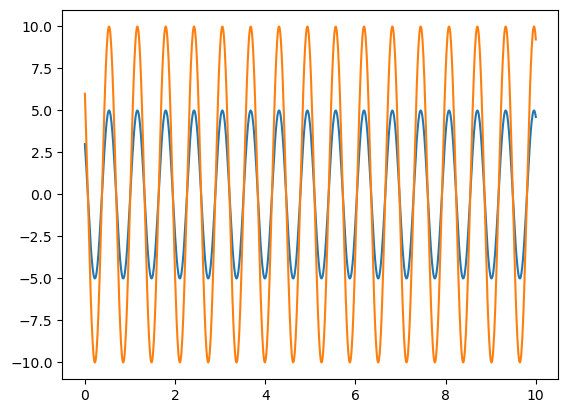

In [21]:
import numpy as np

a = np.array([1 + 2j, 3 + 4j, 5 + 6j])
mod = np.abs(a)
print(mod)

phase = np.rad2deg(np.angle(a))
print(phase)

v = np.array([1,0,0])

b = np.cross(v,mod)
b = b*np.exp(1j*phase)
print(b)
print(np.rad2deg(np.angle(b)))

c = np.cross(v, a)
print(c)
print(np.rad2deg(np.angle(c)))


com = 3+4j
w = 10

t = np.linspace(0,10,1000)
ft = com*np.exp(1j*w*t)

ft1 = ft*2

import matplotlib.pyplot as plt

plt.plot(t, ft.real)
plt.plot(t, ft1.real)

print(np.max(ft.real))



In [23]:
import numpy as np
a = np.diag((1,2,3,4,5,6))
a = np.arange(72).reshape(3, 3, 2, 4)
Xi = np.arange(72).reshape(3, 6, 4)

b = a[:,:,0, :] + Xi[:, 0:3, :]
print(b.shape)
print(b[0,:,0])

vec = np.array([0,0,100])

tmp = np.cross(b, np.array([0,0,100]), axisa=1, axisc=1)
print(tmp.shape)
print(tmp[0,:,0])

print(b[:,0,:])
# print(tmp[0,0:3,0,0])

# tmp = np.stack((a, a))
# print(tmp.shape)
# tmp_ = np.transpose(np.transpose(tmp, (2, 0, 1)), (0, 2, 1))
# print(tmp[0])

# print(tmp_[:,:,1])

# tmp = a.flatten()
# print(tmp)
# print(tmp.reshape(2,36))
# tmp.reshape(2,36).reshape(2,6,6)

(3, 3, 4)
[ 0 12 24]
(3, 3, 4)
[1200    0    0]
[[  0   2   4   6]
 [ 48  50  52  54]
 [ 96  98 100 102]]


In [2]:
import xarray as xr
import numpy as np
test_matrix = xr.Dataset(coords={

    'omega': np.linspace(0.1, 1.8, 20),
    'wave_direction': np.linspace(0, np.pi/2, 2),
    'water_depth': [np.inf],
})

print(test_matrix)

<xarray.Dataset> Size: 184B
Dimensions:         (omega: 20, wave_direction: 2, water_depth: 1)
Coordinates:
  * omega           (omega) float64 160B 0.1 0.1895 0.2789 ... 1.621 1.711 1.8
  * wave_direction  (wave_direction) float64 16B 0.0 1.571
  * water_depth     (water_depth) float64 8B inf
Data variables:
    *empty*
